# README – Transfer Learning with TensorFlow (Part 2: Fine-Tuning)

## Notebook Purpose

This notebook builds on transfer learning by moving from frozen feature extraction to fine-tuning a pre-trained image classification model on a 10-class food dataset. The main goal was to understand how selectively unfreezing layers can improve performance by adapting learned ImageNet features to the target task.

## Data and Setup

- Reused the same 10-class food dataset with separate training and test directories.
- Built TensorFlow image pipelines with resizing, batching, and label encoding for multi-class classification.
- Started from a previously trained feature extraction model instead of training a new model from scratch.

## Fine-Tuning Strategy and Models

- Used a pre-trained `EfficientNetB0` model as the backbone for transfer learning.
- First trained the classifier head with the base model frozen, then switched to fine-tuning by unfreezing the top layers of the network.
- Kept lower layers frozen and retrained only the higher-level layers so the model could adapt domain-specific visual features without destroying the general representations learned during pretraining.
- Reduced the learning rate during fine-tuning to make weight updates smaller and more stable.

## Training, Tracking, and Evaluation

- Compiled the model with Adam, categorical crossentropy, and accuracy as the main metric.
- Trained and compared the feature extraction and fine-tuned versions using TensorBoard logs and learning curves.
- Evaluated whether fine-tuning improved validation performance over the frozen baseline and observed the tradeoff between better accuracy and higher overfitting risk.

## Key Takeaways

- Practiced the full workflow of fine-tuning after feature extraction in TensorFlow/Keras.
- Learned why fine-tuning usually requires a lower learning rate and careful layer unfreezing.
- Reinforced the difference between using a model as a fixed feature extractor and adapting part of the backbone to the new dataset.

Now we're going to cover another type of transfer learning: **fine-tuning**.  

In fine-tuning transfer learning the pre-trained model weights from another model are unfrozen and tweaked during to better suit your own data.

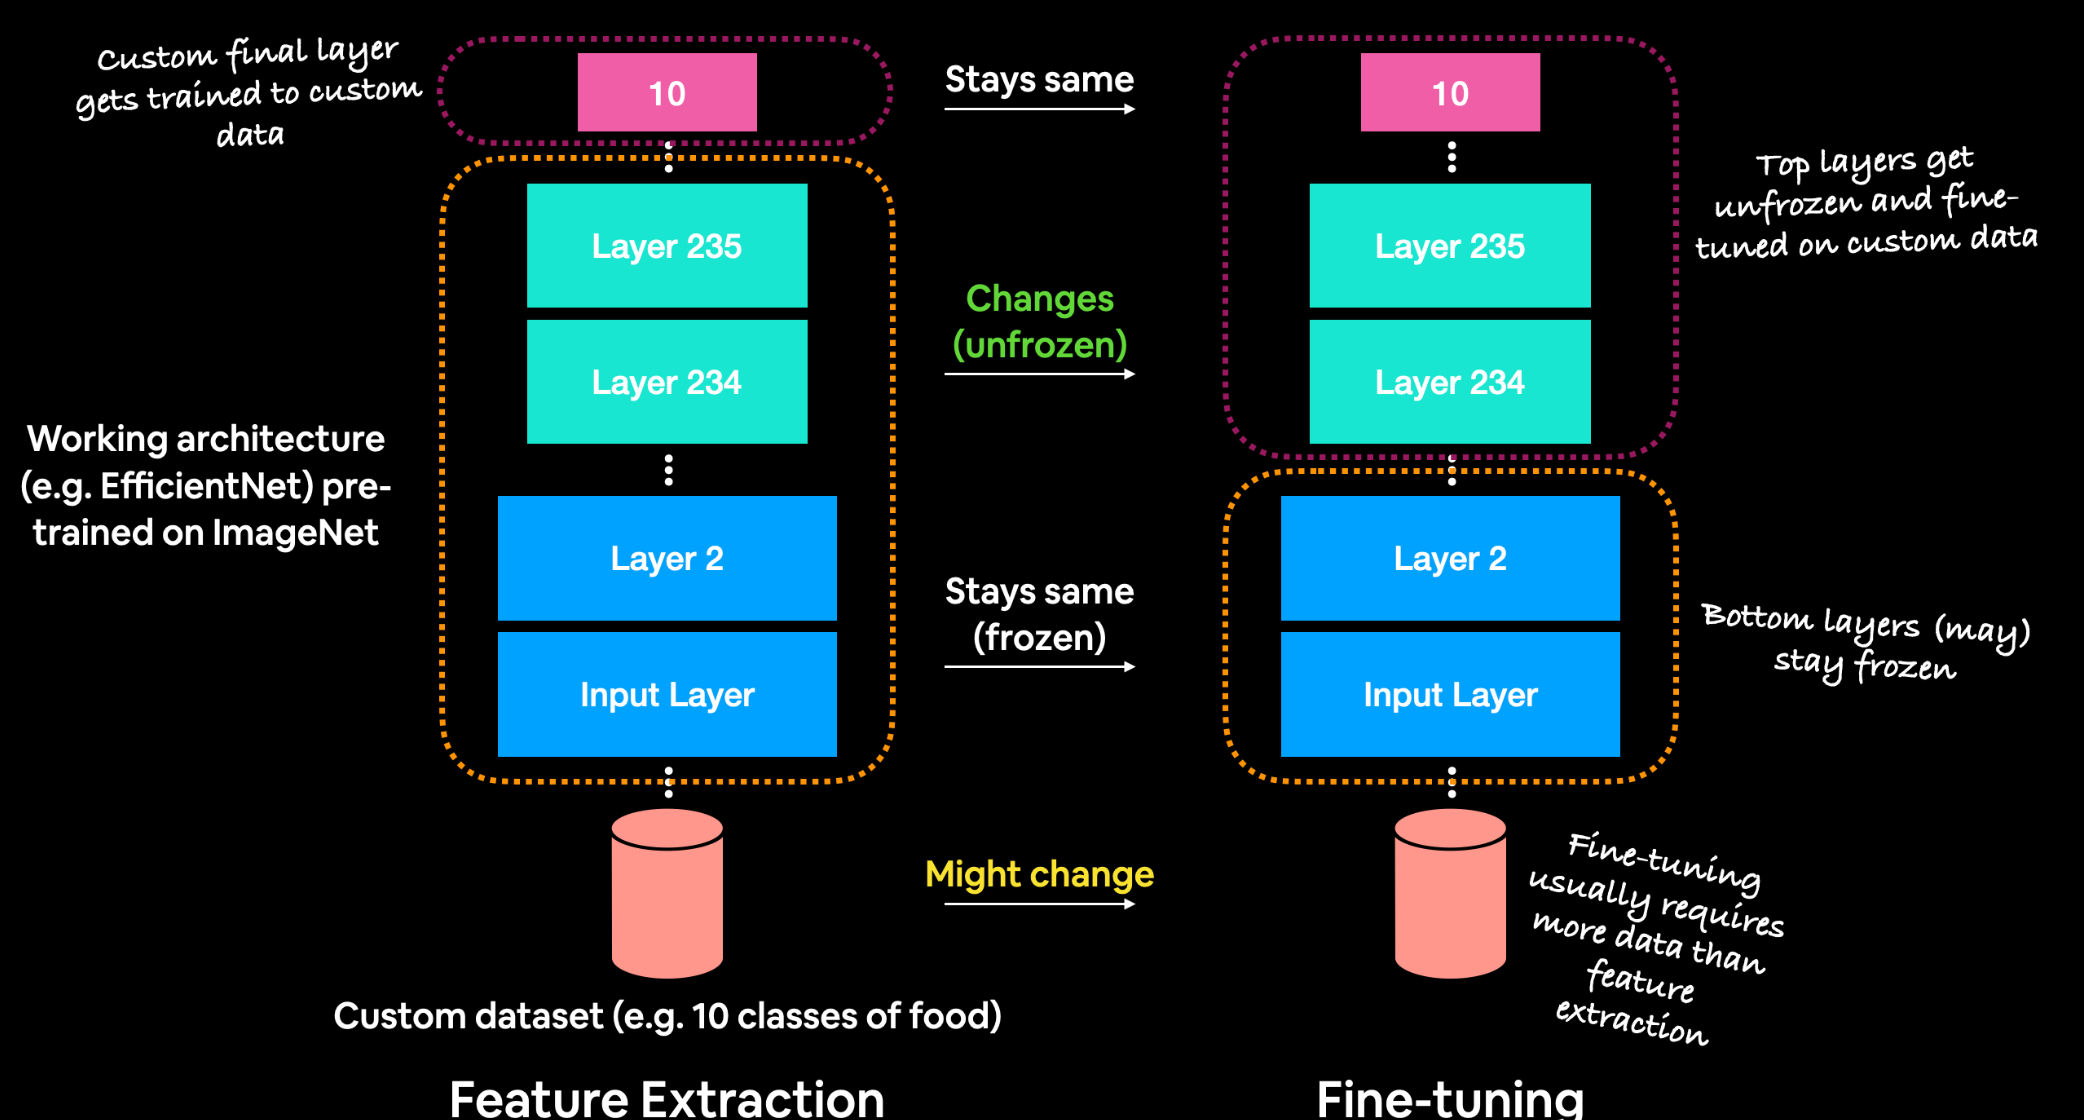

Running a series of modelling experiments on our Food Vision data  
* **Model 0**: a transfer learning model using the Keras Functional API
* **Model 1**: a feature extraction transfer learning model on 1% of the data with data augmentation
* **Model 2**: a feature extraction transfer learning model on 10% of the data with data augmentation
* **Model 3**: a fine-tuned transfer learning model on 10% of the data
* **Model 4**: a fine-tuned transfer learning model on 100% of the data

In [7]:
#import helper function
from pathlib import Path
import os

file_path = Path("helper_functions.py")
url = "https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py"

if not file_path.exists():
    !wget -O helper_functions.py {url}
else:
    print("helper_functions.py already exists, skipping download.")

from helper_functions import (
    create_tensorboard_callback,
    plot_loss_curves,
    unzip_data,
    walk_through_dir,
)

helper_functions.py already exists, skipping download.


In [8]:
# Walk through 10 percent data directory and list number of files
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/test'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/steak'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test

In [10]:
# Create training and test directories
train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

# Create data inputs
import tensorflow as tf
IMG_SIZE = (224, 224) # define image size

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical", # what type are the labels?
                                                                            batch_size=32) # batch_size is 32 by default, this is generally a good number
test_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                           image_size=IMG_SIZE,
                                                                           label_mode="categorical")
     

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [12]:
# Check the training data datatype
print(train_data_10_percent)
# Check out the class names of our dataset
train_data_10_percent.class_names
     

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>


['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [13]:
# See an example batch of data
for images, labels in train_data_10_percent.take(1):
  print(images, labels)

tf.Tensor(
[[[[114.801025   57.80102    49.51531  ]
   [109.2602     57.117348   44.188778 ]
   [101.438774   51.5        51.64796  ]
   ...
   [122.71429    37.714287   60.714287 ]
   [117.92347    32.92347    55.92347  ]
   [122.28585    37.285854   60.285854 ]]

  [[110.28571    52.92857    47.       ]
   [105.42857    53.285713   42.35714  ]
   [100.85715    51.071426   51.540817 ]
   ...
   [121.499954   36.499954   59.499954 ]
   [121.         36.         59.       ]
   [120.765274   35.765274   58.765274 ]]

  [[112.42347    56.367348   54.510204 ]
   [105.27041    55.05612    46.55612  ]
   [101.92857    53.5        55.428574 ]
   ...
   [120.68875    35.68875    58.68875  ]
   [122.62756    37.62756    60.62756  ]
   [122.785675   37.78568    60.78568  ]]

  ...

  [[105.28576    80.28576    75.50002  ]
   [103.77043    78.77043    73.77043  ]
   [106.68875    81.26018    75.831604 ]
   ...
   [ 19.403118   10.403117   39.831646 ]
   [ 22.086687   13.086688   42.515217 ]
   [ 

## Model 0: Building a transfer learning model using the Keras Functional API  
To do so we're going to be using the `tf.keras.applications` module as it contains a series of already trained (on ImageNet) computer vision models as well as the Keras Functional API to construct our model.

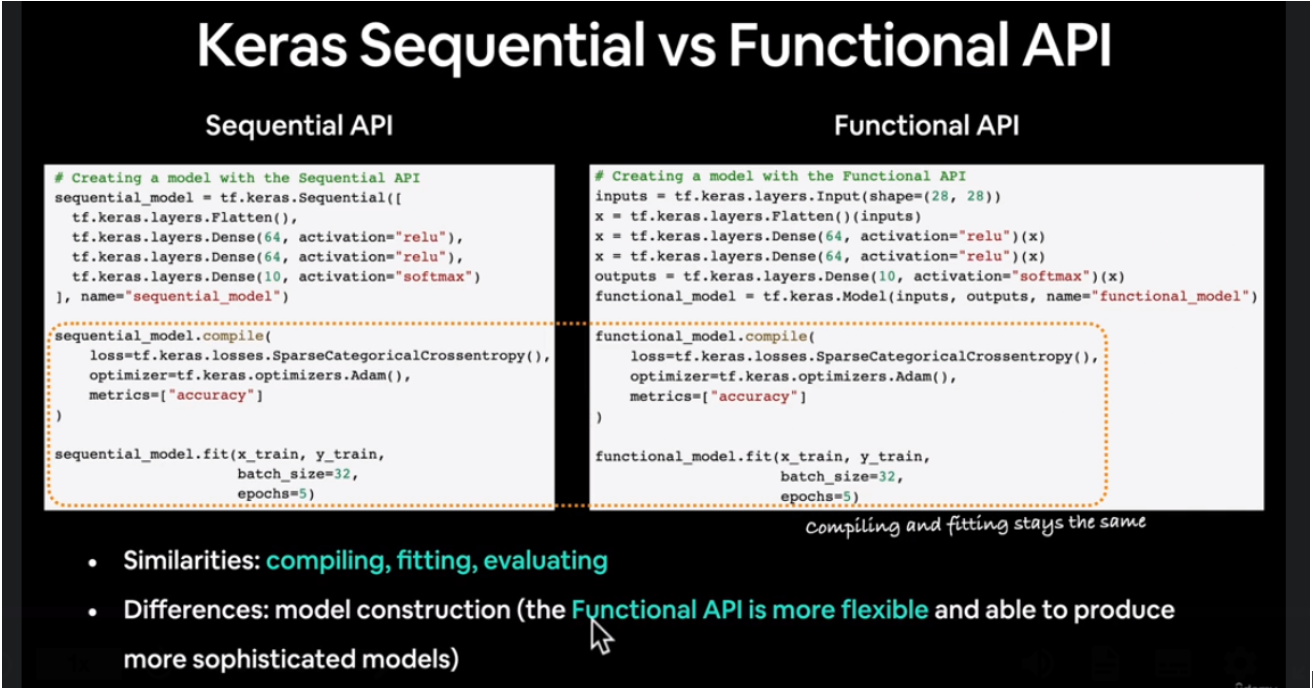

In [14]:
# 1. Load the base model (pretrained EfficientNetV2B0 without the top classification head)
base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights="imagenet")

# 2. Freeze the base model so its pretrained weights don't change during initial training
base_model.trainable = False

# 3. Build the final model by stacking: input -> base_model -> classifier
model_0 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10, activation="softmax"),
])

# 9. Compile the model
model_0.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# 10. Fit the model (we use less steps for validation so it's faster)
history_10_percent = model_0.fit(train_data_10_percent,
                                 epochs=5,
                                 steps_per_epoch=len(train_data_10_percent),
                                 validation_data=test_data_10_percent,
                                 # Go through less of the validation data so epochs are faster (we want faster experiments!)
                                 validation_steps=int(0.25 * len(test_data_10_percent)),
                                 # Track our model's training logs for visualization later
                                 callbacks=[create_tensorboard_callback("transfer_learning", "10_percent_feature_extract")])

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Saving TensorBoard log files to: transfer_learning/10_percent_feature_extract/20260423-084557
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step - accuracy: 0.3907 - loss: 1.8931 - val_accuracy: 0.7220 - val_loss: 1.3386
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.7427 - loss: 1.1428 - val_accuracy: 0.8026 - val_loss: 0.9160
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.8240 - loss: 0.8337 - val_accuracy: 0.8339 - val_loss: 0.7430
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.8480 - loss: 0.6881 - val_accuracy: 0.8454 - val_loss: 0.6466
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.8600 - loss: 0.5967 - val_accuracy: 0.8487 - val_loss: 0.6052


In [15]:
# Check layers in our base model
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name)

0 input_layer
1 rescaling
2 normalization
3 stem_conv
4 stem_bn
5 stem_activation
6 block1a_project_conv
7 block1a_project_bn
8 block1a_project_activation
9 block2a_expand_conv
10 block2a_expand_bn
11 block2a_expand_activation
12 block2a_project_conv
13 block2a_project_bn
14 block2b_expand_conv
15 block2b_expand_bn
16 block2b_expand_activation
17 block2b_project_conv
18 block2b_project_bn
19 block2b_drop
20 block2b_add
21 block3a_expand_conv
22 block3a_expand_bn
23 block3a_expand_activation
24 block3a_project_conv
25 block3a_project_bn
26 block3b_expand_conv
27 block3b_expand_bn
28 block3b_expand_activation
29 block3b_project_conv
30 block3b_project_bn
31 block3b_drop
32 block3b_add
33 block4a_expand_conv
34 block4a_expand_bn
35 block4a_expand_activation
36 block4a_dwconv2
37 block4a_bn
38 block4a_activation
39 block4a_se_squeeze
40 block4a_se_reshape
41 block4a_se_reduce
42 block4a_se_expand
43 block4a_se_excite
44 block4a_project_conv
45 block4a_project_bn
46 block4b_expand_conv
47 b

In [21]:
# %load_ext tensorboard
# %tensorboard --logdir transfer_learning
# !tensorboard --logdir=transfer_learning --port=6007

In [24]:
# plot_loss_curves(history=history_10_percent)

## Model 1: Use feature extraction transfer learning on 1% of the training data with data augmentation.

In [42]:
from pathlib import Path

# Define paths
zip_path = Path("10_food_classes_1_percent.zip")
data_dir = Path("10_food_classes_1_percent")

# Download only if the zip file doesn't already exist
if not zip_path.exists():
    !wget -O {zip_path} https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
else:
    print(f"{zip_path} already exists, skipping download.")

# Unzip only if the extracted folder doesn't already exist
if not data_dir.exists():
    unzip_data(zip_path)
else:
    print(f"{data_dir} already exists, skipping unzip.")

# Create training and test dirs
train_dir_1_percent = data_dir / "train"
test_dir = data_dir / "test"

10_food_classes_1_percent.zip already exists, skipping download.
10_food_classes_1_percent already exists, skipping unzip.


In [27]:
# Walk through 1 percent data directory and list number of files
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/test'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/steak'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/fried_rice'

In [28]:
import tensorflow as tf

IMG_SIZE = (224, 224)

train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_1_percent,
                                                                           label_mode="categorical",
                                                                           batch_size=32, # default
                                                                           image_size=IMG_SIZE)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)
     

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


### data augmentation  
The data augmentation transformations we're going to use are:  

`tf.keras.layers.RandomFlip` - flips image on horizontal or vertical axis.  
`tf.keras.layersRandomRotation `- randomly rotates image by a specified amount.  
`tf.keras.layers.RandomZoom` - randomly zooms into an image by specified amount.  
`tf.keras.layers.RandomHeight `- randomly shifts image height by a specified amount.  
`tf.keras.layers.RandomWidth` - randomly shifts image width by a specified amount.  
`tf.keras.layers.Rescaling` - normalizes the image pixel values to be between 0 and 1, this is worth mentioning because it is required for some image models but since we're using `tf.keras.applications.efficientnet_v2.EfficientNetV2B0`, it's not required (the model pretrained model implements rescaling itself).  

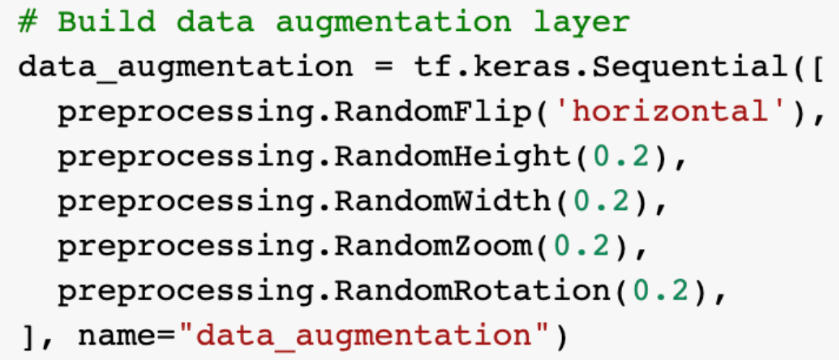

In [37]:
# Adding data augmentation right into the model

# data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),# horizontal_flip=True
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
    # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetV2B0
    ], name="data_augmentation")

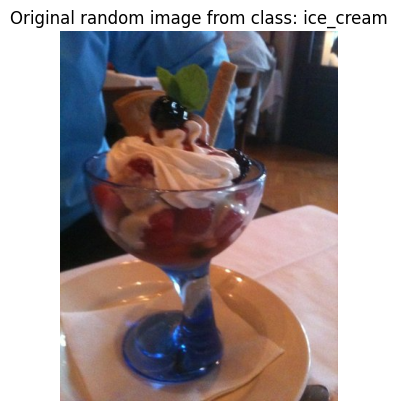

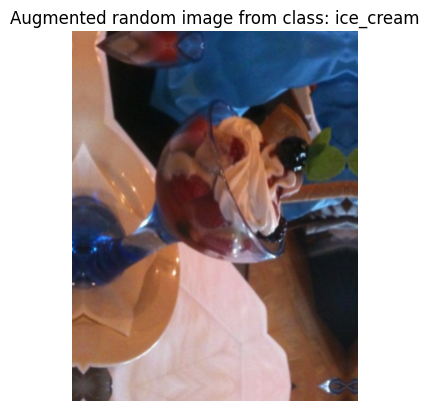

In [35]:
# View a random image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

target_class = random.choice(train_data_1_percent.class_names) # choose a random class
target_dir = "10_food_classes_1_percent/train/" + target_class # create the target directory
random_image = random.choice(os.listdir(target_dir)) # choose a random image from target directory
random_image_path = target_dir + "/" + random_image # create the choosen random image path
img = mpimg.imread(random_image_path) # read in the chosen target image
plt.imshow(img) # plot the target image
plt.title(f"Original random image from class: {target_class}")
plt.axis(False); # turn off the axes

# Augment the image
augmented_img = data_augmentation(tf.expand_dims(img, axis=0)) # data augmentation model requires shape (None, height, width, 3)
plt.figure()
plt.imshow(tf.squeeze(augmented_img)/255.) # requires normalization after augmentation
plt.title(f"Augmented random image from class: {target_class}")
plt.axis(False);

In [38]:
from tensorflow.keras import layers
from tensorflow import keras

#####Sequential API######################################################
# # Set up the pretrained base model
# base_model = tf.keras.applications.EfficientNetV2B0(
#     include_top=False,
#     weights="imagenet",
#     pooling="avg"
# )

# # Freeze the base model so only the classifier learns at first
# base_model.trainable = False

# # Build the model in Sequential format
# model_1 = keras.Sequential([
#     layers.Input(shape=(224, 224, 3)),          # input images
#     data_augmentation,                          # data augmentation layer/model
#     base_model,                                 # pretrained feature extractor
#     layers.Dense(10, activation="softmax")      # output layer for 10 classes
# ], name="model_1")

#####FUNCTIONAL API#######################################################
# Setup input shape and base model, freezing the base model layers
# 1. Base model (pretrained EfficientNetV2B0 without top classifier)
input_shape = (224, 224, 3)
base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze pretrained weights

# 2. Functional graph: inputs -> augmentation -> base model -> pooling -> classifier
inputs = layers.Input(shape=input_shape, name="input_layer")
x = data_augmentation(inputs)                              # data augmentation
x = base_model(x, training=False)                          # frozen backbone in inference mode
x = layers.GlobalAveragePooling2D(name="gap_layer")(x)     # spatial pooling
outputs = layers.Dense(10, activation="softmax",
                       name="output_layer")(x)             # classifier

model_1 = keras.Model(inputs=inputs, outputs=outputs, name="efficientnetv2_transfer")

# Compile the model
model_1.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_1_percent = model_1.fit(train_data_1_percent,
                    epochs=5,
                    steps_per_epoch=len(train_data_1_percent),
                    validation_data=test_data,
                    validation_steps=int(0.25* len(test_data)), # validate for less steps
                    # Track model training logs
                    callbacks=[create_tensorboard_callback("transfer_learning", "1_percent_data_aug")])

Saving TensorBoard log files to: transfer_learning/1_percent_data_aug/20260423-091744
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1143 - loss: 2.3527 - val_accuracy: 0.2385 - val_loss: 2.1962
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2000 - loss: 2.1501 - val_accuracy: 0.2977 - val_loss: 2.0858
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3714 - loss: 1.9876 - val_accuracy: 0.3553 - val_loss: 1.9965
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4000 - loss: 1.8753 - val_accuracy: 0.3865 - val_loss: 1.9239
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4857 - loss: 1.7691 - val_accuracy: 0.4539 - val_loss: 1.8454


In [39]:
# Check out model summary
model_1.summary()
     

Model: "efficientnetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap_layer                       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,957,744 (22.73 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 25,622 (100.09 KB)

In [40]:

# Evaluate on the test data
results_1_percent_data_aug = model_1.evaluate(test_data)
results_1_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.4624 - loss: 1.8309


[1.8309069871902466, 0.46239998936653137]

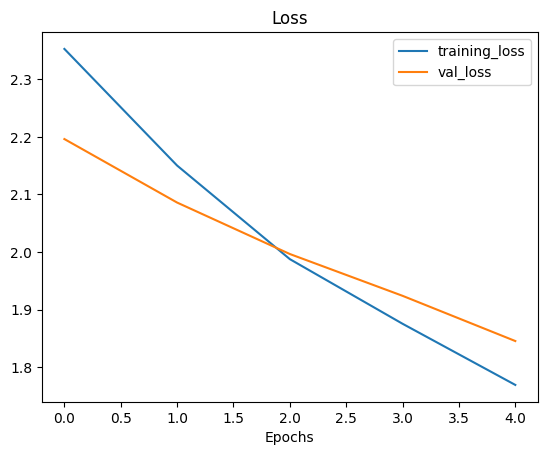

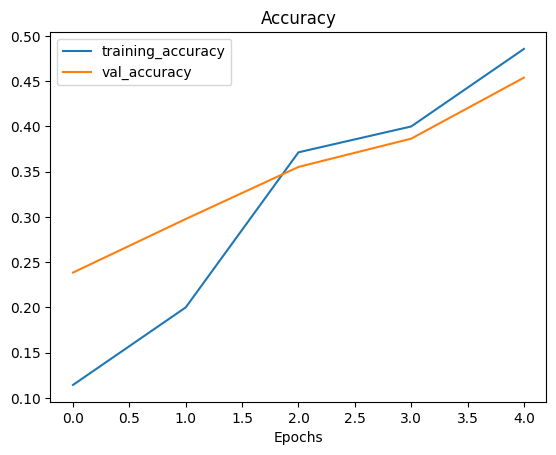

In [41]:

# How does the model go with a data augmentation layer with 1% of data
plot_loss_curves(history_1_percent)

## Model 2: Feature extraction transfer learning with 10% of data and data augmentation

In [43]:
# Get 10% of the data of the 10 classes (uncomment if you haven't gotten "10_food_classes_10_percent.zip" already)
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
# unzip_data("10_food_classes_10_percent.zip")

train_dir_10_percent = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

In [44]:
# Setup data inputs
import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_10_percent,
                                                                            label_mode="categorical",
                                                                            image_size=IMG_SIZE)
# Note: the test data is the same as the previous experiment, we could
# skip creating this, but we'll leave this here to practice.
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [ ]:
from tensorflow.keras import layers
from tensorflow import keras

# data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),# horizontal_flip=True
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetV2B0
    ], name="data_augmentation")

# 1. Base model (pretrained EfficientNetV2B0 without top classifier)
input_shape = (224, 224, 3)

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet")

base_model.trainable = False  # freeze pretrained weights

# 2. Functional graph: inputs -> augmentation -> base model -> pooling -> classifier
inputs = layers.Input(shape=input_shape, name="input_layer")
x = data_augmentation(inputs)                              # data augmentation
x = base_model(x, training=False)                          # frozen backbone in inference mode
x = layers.GlobalAveragePooling2D(name="gap_layer")(x)     # spatial pooling
outputs = layers.Dense(10, activation="softmax", name="output_layer")(x) # classifier

model_2 = keras.Model(inputs=inputs, outputs=outputs, name="model_2")

# Compile the model
model_2.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])


In [45]:
#reuse model later on
def create_base_model(input_shape: tuple[int, int, int] = (224, 224, 3),
                      output_shape: int = 10,
                      learning_rate: float = 0.001,
                      training: bool = False) -> tf.keras.Model:
    """
    Create a model based on EfficientNetV2B0 with built-in data augmentation.

    Parameters:
    - input_shape (tuple): Expected shape of input images. Default is (224, 224, 3).
    - output_shape (int): Number of classes for the output layer. Default is 10.
    - learning_rate (float): Learning rate for the Adam optimizer. Default is 0.001.
    - training (bool): Whether the base model is trainable. Default is False.

    Returns:
    - tf.keras.Model: The compiled model with specified input and output settings.
    """

    # Create base model
    base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
    base_model.trainable = training

    # Setup model input and outputs with data augmentation built-in
    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # pass augmented images to base model but keep it in inference mode
    x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
    outputs = layers.Dense(units=output_shape, activation="softmax", name="output_layer")(x)
    model = tf.keras.Model(inputs, outputs)

    # Compile model
    model.compile(loss="categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])

    return model

# Create an instance of model_2 with our new function
model_2 = create_base_model()

 `ModelCheckpoint` callback

In [47]:
# Setup checkpoint path (weights-only format requires .weights.h5)
checkpoint_path = "ten_percent_model_checkpoints_weights/checkpoint.weights.h5"

# Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,   # only save weights
    save_best_only=True,      # keep only the best weights
    save_freq="epoch",        # save every epoch
    verbose=1
)

In [48]:

# Fit the model saving checkpoints every epoch
initial_epochs = 5
history_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                          epochs=initial_epochs,
                                          validation_data=test_data,
                                          validation_steps=int(0.25 * len(test_data)), # do less steps per validation (quicker)
                                          callbacks=[create_tensorboard_callback("transfer_learning", "10_percent_data_aug"), checkpoint_callback])

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug/20260423-094337
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.2051 - loss: 2.2120
Epoch 1: val_loss improved from None to 1.55628, saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5

Epoch 1: finished saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 346ms/step - accuracy: 0.3147 - loss: 2.0505 - val_accuracy: 0.6151 - val_loss: 1.5563
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.6079 - loss: 1.5186
Epoch 2: val_loss improved from 1.55628 to 1.10456, saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5

Epoch 2: finished saving model to ten_percent_model_checkpoints_weights/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.6280 - loss: 1.4511 - val_accuracy: 0.7385 - val_loss: 1.1046
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.

In [49]:
# Evaluate on the test data
results_10_percent_data_aug = model_2.evaluate(test_data)
results_10_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.8156 - loss: 0.6854


[0.6853877305984497, 0.8155999779701233]

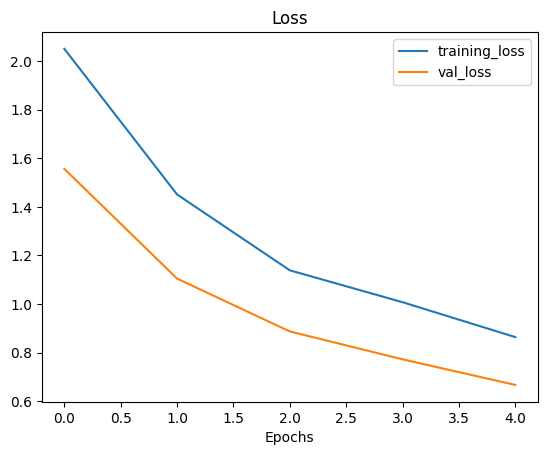

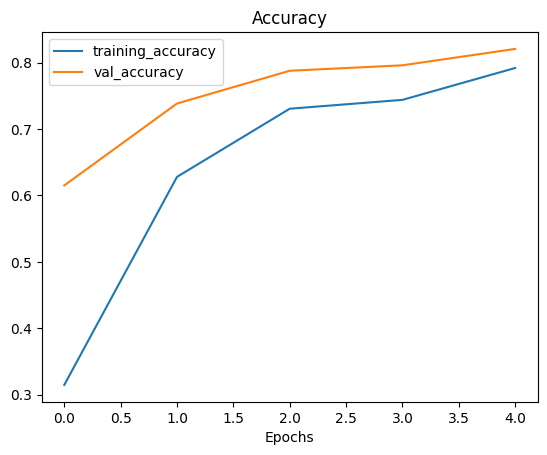

In [51]:

# # Plot model loss curves
# plot_loss_curves(history_10_percent_data_aug)

In [52]:
# Load in saved model weights and evaluate model
model_2.load_weights(checkpoint_path)
loaded_weights_model_results = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.8156 - loss: 0.6854


In [53]:
# If the results from our native model and the loaded weights are the same, this should output True
results_10_percent_data_aug == loaded_weights_model_results
     

False

In [55]:
import numpy as np
# Check to see if loaded model results are very close to native model results (should output True)
np.isclose(np.array(results_10_percent_data_aug), np.array(loaded_weights_model_results))


# Check the difference between the two results (small values)
print(np.array(results_10_percent_data_aug) - np.array(loaded_weights_model_results))

[-2.38418579e-07  0.00000000e+00]


## Model 3: Fine-tuning an existing model on 10% of the data

In [56]:
# Layers in loaded model
model_2.layers

[<InputLayer name=input_layer, built=True>,
 <Sequential name=data_augmentation, built=True>,
 <Functional name=efficientnetv2-b0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling_layer, built=True>,
 <Dense name=output_layer, built=True>]

In [57]:
for layer_number, layer in enumerate(model_2.layers):
  print(f"Layer number: {layer_number} | Layer name: {layer.name} | Layer type: {layer} | Trainable? {layer.trainable}")
     

Layer number: 0 | Layer name: input_layer | Layer type: <InputLayer name=input_layer, built=True> | Trainable? True
Layer number: 1 | Layer name: data_augmentation | Layer type: <Sequential name=data_augmentation, built=True> | Trainable? True
Layer number: 2 | Layer name: efficientnetv2-b0 | Layer type: <Functional name=efficientnetv2-b0, built=True> | Trainable? False
Layer number: 3 | Layer name: global_average_pooling_layer | Layer type: <GlobalAveragePooling2D name=global_average_pooling_layer, built=True> | Trainable? True
Layer number: 4 | Layer name: output_layer | Layer type: <Dense name=output_layer, built=True> | Trainable? True


In [58]:
model_2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,957,744 (22.73 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 25,622 (100.09 KB)

In [59]:

# Access the base_model layers of model_2
model_2_base_model = model_2.layers[2]
model_2_base_model.name

'efficientnetv2-b0'

In [60]:
# How many layers are trainable in our model_2_base_model?
print(len(model_2_base_model.trainable_variables)) # layer at index 2 is the EfficientNetV2B0 layer (the base model)

0


In [61]:
# Check which layers are tuneable (trainable)
for layer_number, layer in enumerate(model_2_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_6 False
1 rescaling_3 False
2 normalization_3 False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dw

In [62]:
# Make all the layers in model_2_base_model trainable
model_2_base_model.trainable = True

# Freeze all layers except for the last 10
for layer in model_2_base_model.layers[:-10]:
  layer.trainable = False

# Recompile the whole model (always recompile after any adjustments to a model)
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr is 10x lower than before for fine-tuning
                metrics=["accuracy"])

In [63]:
print(len(model_2.trainable_variables))

12


In [64]:
# Fine tune for another 5 epochs
fine_tune_epochs = initial_epochs + 5

# Refit the model (same as model_2 except with more trainable layers)
history_fine_10_percent_data_aug = model_2.fit(train_data_10_percent,
                                               epochs=fine_tune_epochs,
                                               validation_data=test_data,
                                               initial_epoch=history_10_percent_data_aug.epoch[-1], # start from previous last epoch
                                               validation_steps=int(0.25 * len(test_data)),
                                               callbacks=[create_tensorboard_callback("transfer_learning", "10_percent_fine_tune_last_10")]) # name experiment appropriately

Saving TensorBoard log files to: transfer_learning/10_percent_fine_tune_last_10/20260423-120258
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.7533 - loss: 1.0398 - val_accuracy: 0.8257 - val_loss: 0.7135
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.7853 - loss: 0.9070 - val_accuracy: 0.8372 - val_loss: 0.6397
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 292ms/step - accuracy: 0.8040 - loss: 0.8442 - val_accuracy: 0.8470 - val_loss: 0.6013
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.8080 - loss: 0.7709 - val_accuracy: 0.8520 - val_loss: 0.5565
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step - accuracy: 0.8293 - loss: 0.7502 - val_accuracy: 0.8586 - val_loss: 0.5254
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 304ms/step - accuracy: 0.8227 - loss: 0.7148 - val_accuracy: 0.8586 - val_loss: 0.5364


In [65]:

# Evaluate the model on the test data
results_fine_tune_10_percent = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.8476 - loss: 0.5296


In [66]:
def compare_historys(original_history, new_history, initial_epochs=5):
    """
    Compares two model history objects.
    """
    # Get original history measurements
    acc = original_history.history["accuracy"]
    loss = original_history.history["loss"]

    print(len(acc))

    val_acc = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    # Combine original history with new history
    total_acc = acc + new_history.history["accuracy"]
    total_loss = loss + new_history.history["loss"]

    total_val_acc = val_acc + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    print(len(total_acc))
    print(total_acc)

    # Make plots
    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    plt.plot(total_acc, label='Training Accuracy')
    plt.plot(total_val_acc, label='Validation Accuracy')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 1, 2)
    plt.plot(total_loss, label='Training Loss')
    plt.plot(total_val_loss, label='Validation Loss')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()
     

5
11
[0.31466665863990784, 0.628000020980835, 0.7306666374206543, 0.7440000176429749, 0.7919999957084656, 0.753333330154419, 0.7853333353996277, 0.8040000200271606, 0.8080000281333923, 0.8293333053588867, 0.8226666450500488]


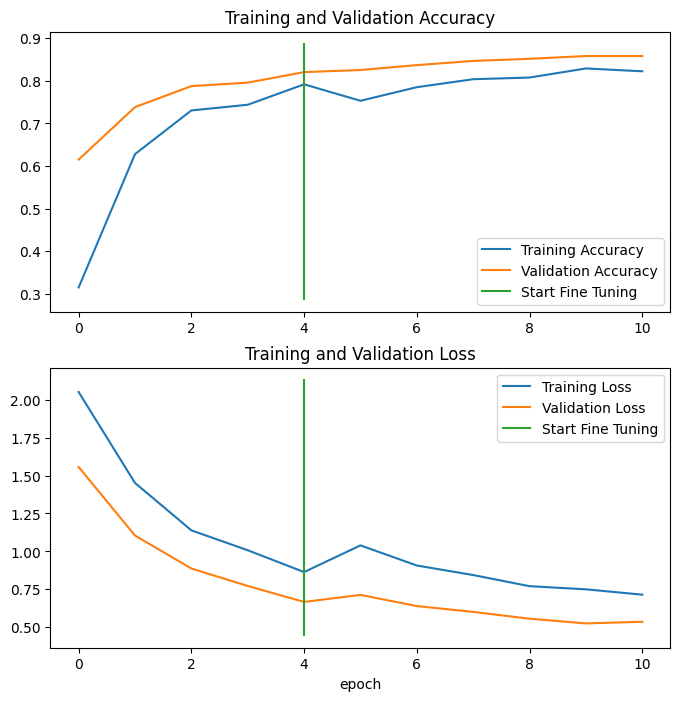

In [67]:

compare_historys(original_history=history_10_percent_data_aug,
                 new_history=history_fine_10_percent_data_aug,
                 initial_epochs=5)

## Model 4: Fine-tuning an existing model all of the data


In [68]:
from pathlib import Path

zip_path = Path("10_food_classes_all_data.zip")
data_dir = Path("10_food_classes_all_data")

# Download only if the zip file doesn't already exist
if not zip_path.exists():
    !wget -O {zip_path} https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
else:
    print(f"{zip_path} already exists, skipping download.")

# Unzip only if the extracted folder doesn't already exist
if not data_dir.exists():
    unzip_data(zip_path)
else:
    print(f"{data_dir} already exists, skipping unzip.")

# Setup data directories
train_dir = data_dir / "train"
test_dir = data_dir / "test"

10_food_classes_all_data.zip already exists, skipping download.
10_food_classes_all_data already exists, skipping unzip.


In [69]:
# Setup data inputs
import tensorflow as tf
IMG_SIZE = (224, 224)

train_data_10_classes_full = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                 label_mode="categorical",
                                                                                 image_size=IMG_SIZE)

# Note: this is the same test dataset we've been using for the previous modelling experiments
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [70]:
# Create a new instance of model_2 for Experiment 4
model_2 = create_base_model(learning_rate=0.0001) # 10x lower learning rate for fine-tuning

In [71]:
# Load previously checkpointed weights
model_2.load_weights(checkpoint_path)

/home/paminidigehsara/Desktop/controlEx_prep/.venv_ce/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [72]:
model_2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, None, None,     │     5,919,312 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [73]:
print(len(model_2.trainable_variables))

2


In [74]:
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - accuracy: 0.8156 - loss: 0.6854


[0.685387909412384, 0.8155999779701233]

In [75]:
# Check which layers are tuneable in the whole model
for layer_number, layer in enumerate(model_2.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer True
1 data_augmentation True
2 efficientnetv2-b0 False
3 global_average_pooling_layer True
4 output_layer True


In [76]:
# Unfreeze the top 10 layers in model_2's base_model
model_2_base_model = model_2.layers[2]
model_2_base_model.trainable = True

# Freeze all layers except for the last 10
for layer in model_2_base_model.layers[:-10]:
  layer.trainable = False

In [77]:
# # Check which layers are tuneable in the base model
# for layer_number, layer in enumerate(model_2_base_model.layers):
#   print(layer_number, layer.name, layer.trainable)
     



0 input_layer_7 False
1 rescaling_4 False
2 normalization_4 False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dw

In [78]:
# Recompile the model (always recompile after any adjustments to a model)
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr is 10x lower than before for fine-tuning
                metrics=["accuracy"])
     

In [79]:
# Continue to train and fine-tune the model to our data
fine_tune_epochs = initial_epochs + 5

history_fine_10_classes_full = model_2.fit(train_data_10_classes_full,
                                           epochs=fine_tune_epochs,
                                           initial_epoch=history_10_percent_data_aug.epoch[-1],
                                           validation_data=test_data,
                                           validation_steps=int(0.25 * len(test_data)),
                                           callbacks=[create_tensorboard_callback("transfer_learning", "full_10_classes_fine_tune_last_10")])

Saving TensorBoard log files to: transfer_learning/full_10_classes_fine_tune_last_10/20260423-122146
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 51s 200ms/step - accuracy: 0.7387 - loss: 0.9351 - val_accuracy: 0.8586 - val_loss: 0.4611
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 45s 190ms/step - accuracy: 0.7821 - loss: 0.7315 - val_accuracy: 0.8816 - val_loss: 0.3603
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 45s 190ms/step - accuracy: 0.7972 - loss: 0.6582 - val_accuracy: 0.8964 - val_loss: 0.3351
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 197ms/step - accuracy: 0.8093 - loss: 0.6036 - val_accuracy: 0.8997 - val_loss: 0.3237
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 194ms/step - accuracy: 0.8231 - loss: 0.5635 - val_accuracy: 0.9178 - val_loss: 0.2702
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 188ms/step - accuracy: 0.8327 - loss: 0.5325 - val_accuracy: 0.9194 - val_loss: 0.2745


In [80]:
results_fine_tune_full_data = model_2.evaluate(test_data)
results_fine_tune_full_data

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.9172 - loss: 0.2566


[0.256580114364624, 0.9172000288963318]

In [81]:
results_fine_tune_10_percent

[0.5295905470848083, 0.847599983215332]

5
11
[0.31466665863990784, 0.628000020980835, 0.7306666374206543, 0.7440000176429749, 0.7919999957084656, 0.7386666536331177, 0.7821333408355713, 0.7972000241279602, 0.809333324432373, 0.8230666518211365, 0.8326666951179504]


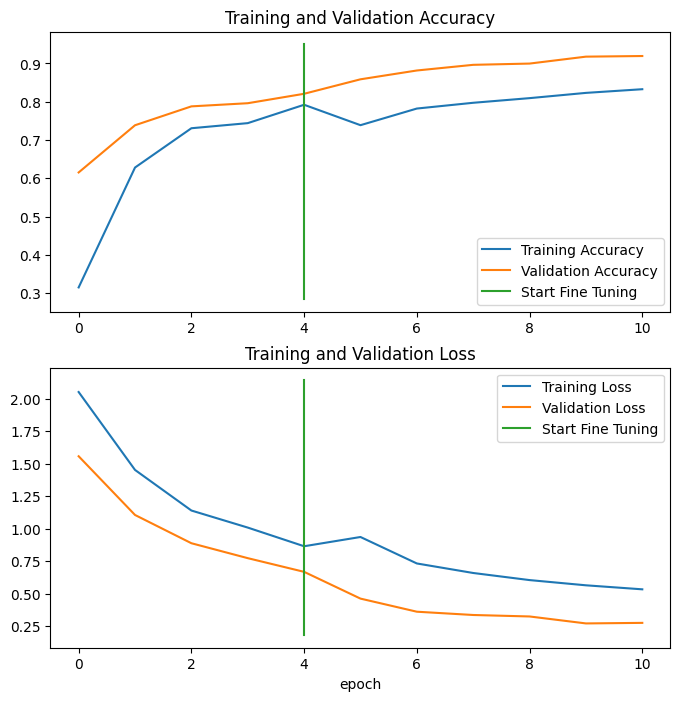

In [82]:
# How did fine-tuning go with more data?
compare_historys(original_history=history_10_percent_data_aug,
                 new_history=history_fine_10_classes_full,
                 initial_epochs=5)

In [84]:
# %load_ext tensorboard
# %tensorboard --logdir transfer_learning
# !tensorboard --logdir=transfer_learning --port=6009